# 🔵 Clustering Analysis — K-Means Prioritas Kecamatan

---

## Tujuan
Mengelompokkan 31 kecamatan Kota Surabaya ke dalam **4 cluster prioritas intervensi**
menggunakan algoritma **K-Means**, berdasarkan fitur SCGI komposit.

---

## Fitur Clustering

| Fitur | Deskripsi | Range |
|---|---|---|
| `deficit_rate` | Proporsi demand tidak terlayani | 0–1 |
| `utilisasi_norm` | Utilisasi ternormalisasi (cap 200%) | 0–1 |
| `growth_rate` | Tekanan pertumbuhan demand 2025→2030 | 0–1 |
| `scgi_raw` | SCGI komposit (0–1) | 0–1 |

Semua fitur sudah ternormalisasi dalam range [0,1] via MinMaxScaler.

## Algoritma: K-Means
$$\underset{\mathcal{S}}{\arg\min} \sum_{i=1}^{K} \sum_{x \in S_i} \|x - \mu_i\|^2$$

Cluster dengan **rata-rata fitur tertinggi** → Priority 1 (KRITIS)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans as SKKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DATA = '../medallion/exports/'

clusters = pd.read_csv(DATA + 'clusters.csv')
elbow    = pd.read_csv(DATA + 'elbow_data.csv')
scgi     = pd.read_csv(DATA + 'scgi.csv')

PRIORITY_COLORS = {1:'#d62728', 2:'#ff7f0e', 3:'#bcbd22', 4:'#2ca02c'}
PRIORITY_LABELS = {1:'KRITIS', 2:'TINGGI', 3:'SEDANG', 4:'RENDAH'}
FEATURE_COLS    = ['deficit_rate','utilisasi_norm','growth_rate','scgi_raw']

print(f'Clusters: {clusters.shape}  |  Priority labels: {clusters["priority_label"].value_counts().to_dict()}')
clusters[['kecamatan_norm','scgi_score','priority_rank','priority_label','cluster_id']].head(10)

Clusters: (31, 17)  |  Priority labels: {'RENDAH': 15, 'SEDANG': 9, 'KRITIS': 6, 'TINGGI': 1}


,kecamatan_norm,scgi_score,priority_rank,priority_label,cluster_id
0,PABEAN CANTIAN,55.37,1,KRITIS,2
1,SAWAHAN,38.65,1,KRITIS,2
2,TAMBAKSARI,37.61,1,KRITIS,2
3,ASEMROWO,37.41,2,TINGGI,1
4,SIMOKERTO,36.09,1,KRITIS,2
5,BUBUTAN,33.44,1,KRITIS,2
6,GUNUNG ANYAR,32.93,1,KRITIS,2
7,SEMAMPIR,31.43,3,SEDANG,3
8,WIYUNG,29.32,3,SEDANG,3
9,TEGALSARI,28.07,3,SEDANG,3


## 1. Elbow Method — Pemilihan K Optimal

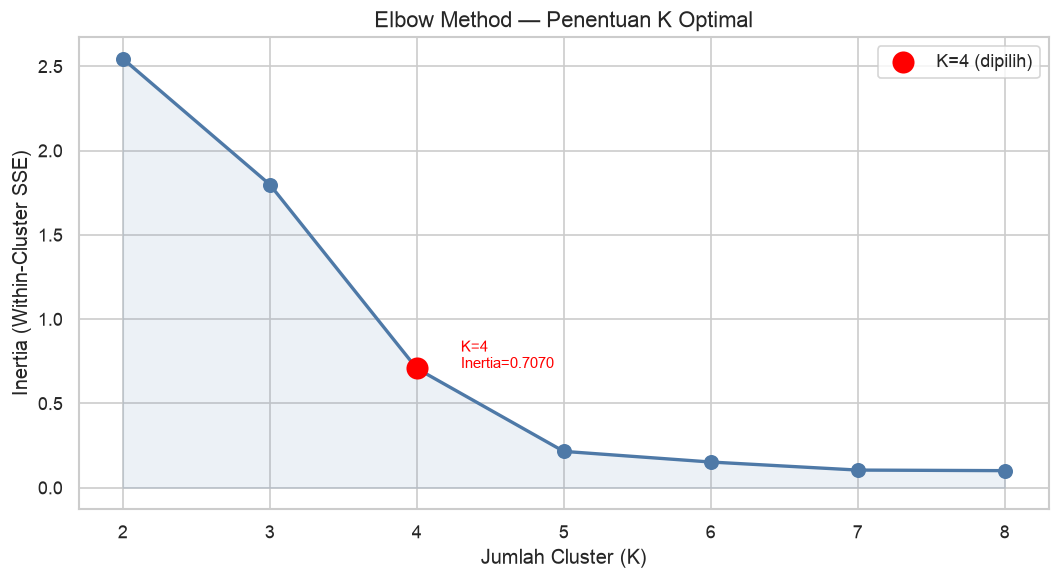


Elbow Data:
 k  inertia
 2   2.5456
 3   1.7988
 4   0.7070
 5   0.2152
 6   0.1520
 7   0.1042
 8   0.1008


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(elbow['k'], elbow['inertia'], 'o-', color='#4E79A7', lw=2, ms=8)
ax.fill_between(elbow['k'], elbow['inertia'], alpha=0.1, color='#4E79A7')

# Annotate K=4 (chosen)
k4_val = elbow.loc[elbow['k']==4, 'inertia'].values[0]
ax.scatter([4], [k4_val], s=150, color='red', zorder=5, label='K=4 (dipilih)')
ax.annotate(f'K=4\nInertia={k4_val:.4f}', (4, k4_val),
             xytext=(4.3, k4_val+0.003), fontsize=9, color='red')

ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_title('Elbow Method — Penentuan K Optimal')
ax.set_xticks(elbow['k'])
ax.legend()
plt.tight_layout()
plt.show()

print('\nElbow Data:')
print(elbow.to_string(index=False))

## 2. Distribusi Cluster & Map Prioritas

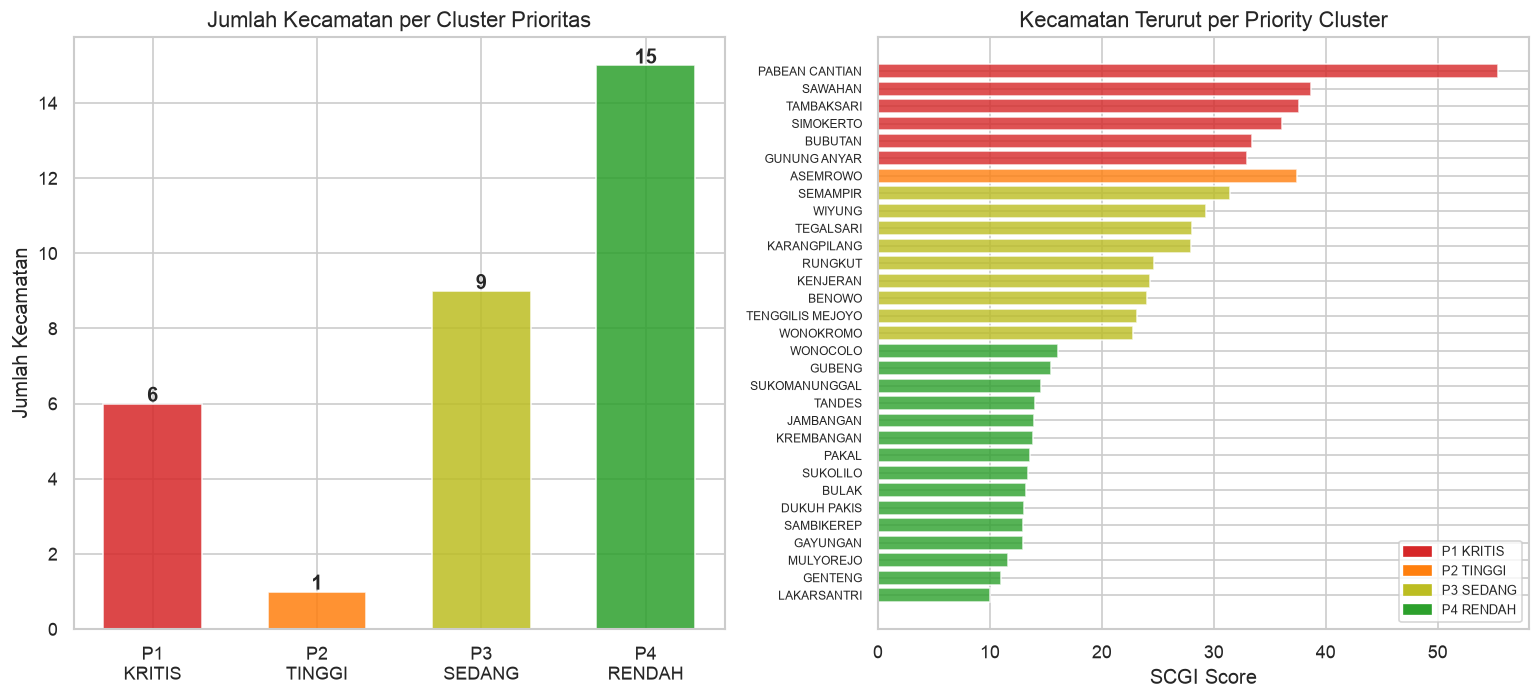

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Bar: kecamatan per cluster
priority_count = clusters.groupby('priority_rank').agg(
    n_kecamatan=('kecamatan_norm','count'),
    scgi_mean=('scgi_score','mean'),
    label=('priority_label','first')
).reset_index()

ax1 = axes[0]
bars = ax1.bar(priority_count['priority_rank'],
                priority_count['n_kecamatan'],
                color=[PRIORITY_COLORS[r] for r in priority_count['priority_rank']],
                alpha=0.85, edgecolor='white', width=0.6)
ax1.set_xticks(priority_count['priority_rank'])
ax1.set_xticklabels([f'P{r}\n{l}' for r,l in zip(priority_count['priority_rank'], priority_count['label'])])
ax1.set_ylabel('Jumlah Kecamatan')
ax1.set_title('Jumlah Kecamatan per Cluster Prioritas')
for bar, val in zip(bars, priority_count['n_kecamatan']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             str(val), ha='center', fontweight='bold')

# Horizontal bar sorted by priority & scgi
ax2 = axes[1]
clus_sorted = clusters.sort_values(['priority_rank','scgi_score'], ascending=[True, False])
y_pos  = range(len(clus_sorted))
colors = [PRIORITY_COLORS[r] for r in clus_sorted['priority_rank']]
ax2.barh(list(y_pos), clus_sorted['scgi_score'], color=colors, alpha=0.8, edgecolor='white')
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(clus_sorted['kecamatan_norm'], fontsize=7)
ax2.set_xlabel('SCGI Score')
ax2.set_title('Kecamatan Terurut per Priority Cluster')
ax2.invert_yaxis()
legend_patches = [mpatches.Patch(color=PRIORITY_COLORS[r], label=f'P{r} {PRIORITY_LABELS[r]}')
                  for r in range(1,5)]
ax2.legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Visualisasi 2D — PCA Projection

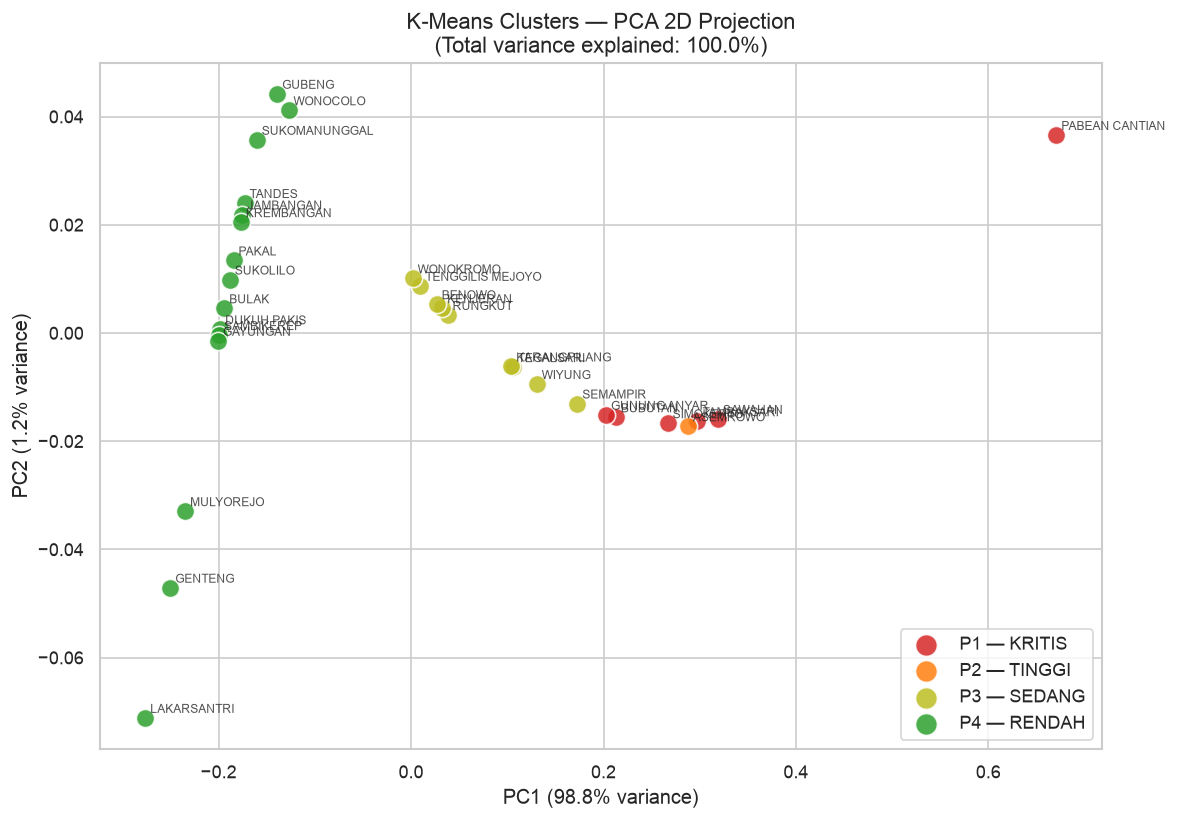

In [4]:
X = clusters[FEATURE_COLS].fillna(0).values
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
for pr in sorted(clusters['priority_rank'].unique()):
    mask = clusters['priority_rank'] == pr
    ax.scatter(X_2d[mask,0], X_2d[mask,1],
               c=PRIORITY_COLORS[pr], s=120, alpha=0.85, edgecolors='white',
               label=f'P{pr} — {PRIORITY_LABELS[pr]}', zorder=3)

for i, row in clusters.reset_index().iterrows():
    ax.annotate(row['kecamatan_norm'], (X_2d[i,0], X_2d[i,1]),
                fontsize=7, alpha=0.8, xytext=(3,3), textcoords='offset points')

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variance)')
ax.set_title(f'K-Means Clusters — PCA 2D Projection\n'
              f'(Total variance explained: {sum(var_exp):.1%})')
ax.legend(markerscale=1.2)
plt.tight_layout()
plt.show()

## 4. Radar Chart — Profil Cluster

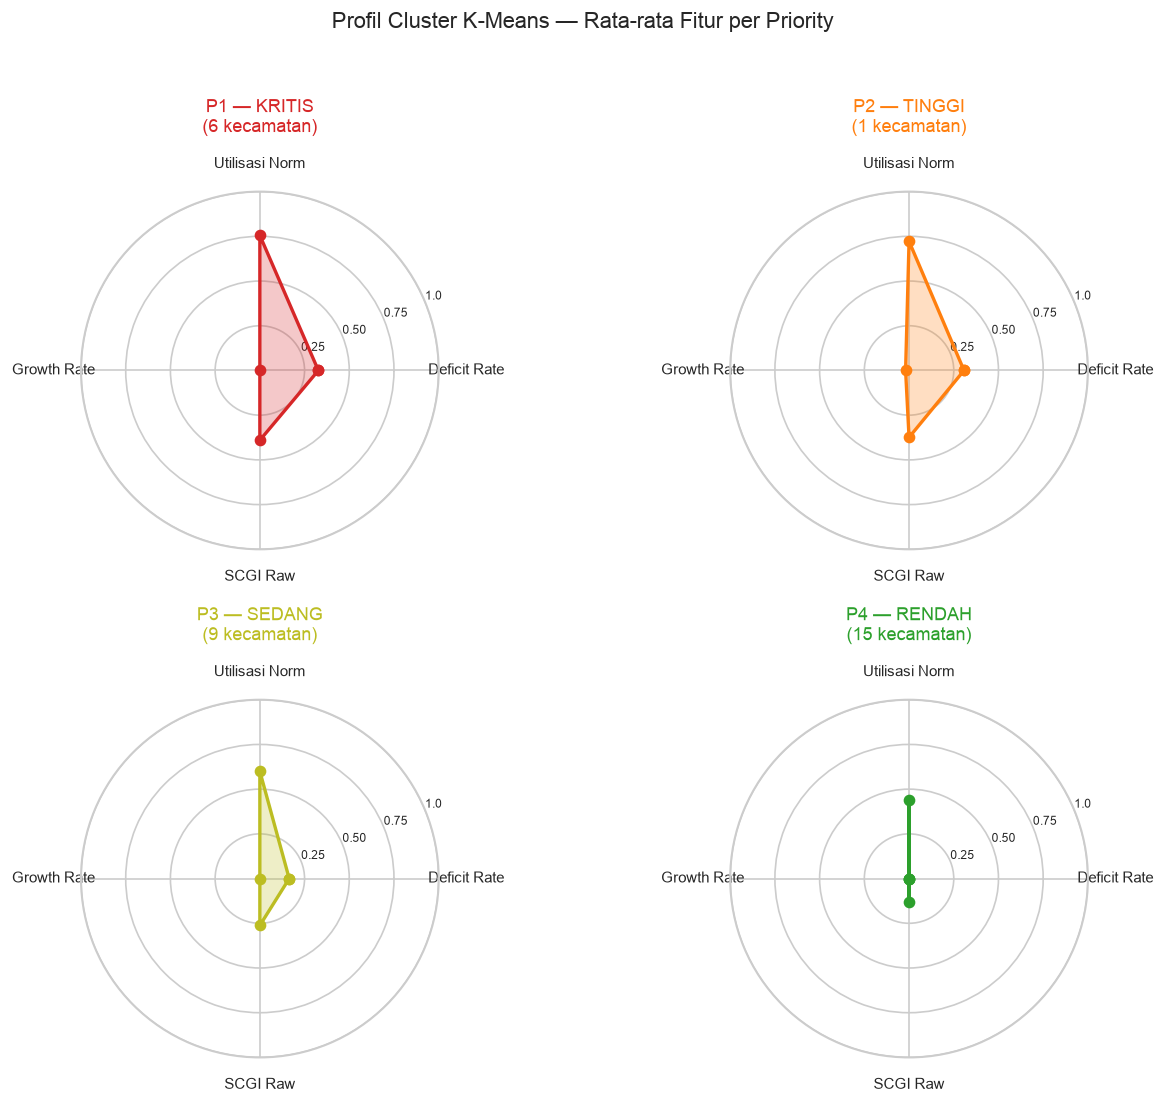


Cluster Profiles (mean features):


,deficit_rate,utilisasi_norm,growth_rate,scgi_raw
priority_rank,,,,
1,0.327,0.755,0.000,0.390
2,0.307,0.722,0.019,0.374
3,0.164,0.600,0.000,0.262
4,0.002,0.441,0.000,0.133


In [5]:
cluster_profiles = clusters.groupby('priority_rank')[FEATURE_COLS].mean()

categories = ['Deficit Rate', 'Utilisasi Norm', 'Growth Rate', 'SCGI Raw']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig = plt.figure(figsize=(11, 9))
for idx, pr in enumerate(sorted(cluster_profiles.index), 1):
    ax = fig.add_subplot(2, 2, idx, polar=True)
    values = cluster_profiles.loc[pr].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, color=PRIORITY_COLORS[pr])
    ax.fill(angles, values, alpha=0.25, color=PRIORITY_COLORS[pr])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'P{pr} — {PRIORITY_LABELS[pr]}\n({(clusters["priority_rank"]==pr).sum()} kecamatan)',
                  fontsize=11, color=PRIORITY_COLORS[pr], pad=15)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.0'], fontsize=7)

plt.suptitle('Profil Cluster K-Means — Rata-rata Fitur per Priority', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print('\nCluster Profiles (mean features):')
cluster_profiles.round(3)

## 5. Evaluasi Cluster (Silhouette & Davies-Bouldin)

  EVALUASI KUALITAS CLUSTER
  Silhouette Score    = 0.4441
  Status              = CUKUP (range: -1 to 1; > 0.5 = Baik)

  Davies-Bouldin Index = 1.5020
  Status               = CUKUP (< 1.0 = Baik, < 2.0 = Cukup)


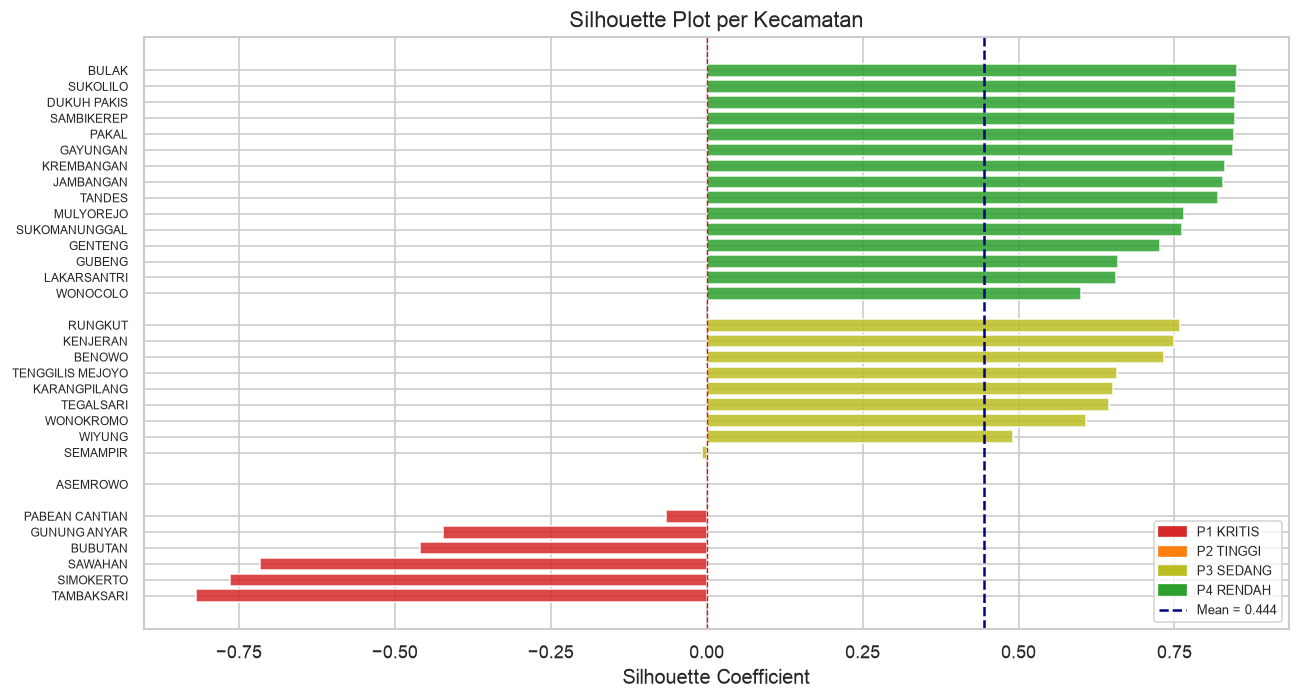

In [6]:
X      = clusters[FEATURE_COLS].fillna(0).values
labels = clusters['priority_rank'].values

sil_score = silhouette_score(X, labels)
db_score  = davies_bouldin_score(X, labels)

print('='*55)
print('  EVALUASI KUALITAS CLUSTER')
print('='*55)
print(f'  Silhouette Score    = {sil_score:.4f}')
sil_status = 'BAIK' if sil_score > 0.5 else ('CUKUP' if sil_score > 0.25 else 'LEMAH')
print(f'  Status              = {sil_status} (range: -1 to 1; > 0.5 = Baik)')
print()
print(f'  Davies-Bouldin Index = {db_score:.4f}')
db_status = 'BAIK' if db_score < 1.0 else ('CUKUP' if db_score < 2.0 else 'LEMAH')
print(f'  Status               = {db_status} (< 1.0 = Baik, < 2.0 = Cukup)')
print('='*55)

# Silhouette per sample
from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(X, labels)
sil_df   = clusters[['kecamatan_norm','priority_rank','priority_label']].copy()
sil_df['silhouette'] = sil_vals

fig, ax = plt.subplots(figsize=(11, 6))
y = 0
y_ticks, y_labels = [], []
for pr in sorted(sil_df['priority_rank'].unique()):
    grp = sil_df[sil_df['priority_rank']==pr].sort_values('silhouette')
    size = len(grp)
    ax.barh(range(y, y+size), grp['silhouette'],
             color=PRIORITY_COLORS[pr], edgecolor='white', alpha=0.85)
    y_ticks += list(range(y, y+size))
    y_labels += list(grp['kecamatan_norm'])
    y += size + 1

ax.axvline(0, color='red', lw=0.8, ls='--')
ax.axvline(sil_score, color='navy', lw=1.5, ls='--', label=f'Mean Silhouette = {sil_score:.3f}')
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=7)
ax.set_xlabel('Silhouette Coefficient')
ax.set_title('Silhouette Plot per Kecamatan')
ax.legend()
legend_patches = [mpatches.Patch(color=PRIORITY_COLORS[r], label=f'P{r} {PRIORITY_LABELS[r]}')
                  for r in range(1,5)]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color='navy',ls='--',
           label=f'Mean = {sil_score:.3f}')], loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 📌 Tabel Lengkap Hasil Clustering

In [7]:
pd.set_option('display.float_format', '{:.3f}'.format)
result_table = (clusters[['priority_rank','priority_label','kecamatan_norm',
                            'scgi_score','scgi_category','cluster_id']]
                .sort_values(['priority_rank','scgi_score'], ascending=[True,False])
                .reset_index(drop=True))
result_table.index += 1
result_table

,priority_rank,priority_label,kecamatan_norm,scgi_score,scgi_category,cluster_id
1,1,KRITIS,PABEAN CANTIAN,55.370,TINGGI,2
2,1,KRITIS,SAWAHAN,38.650,SEDANG,2
3,1,KRITIS,TAMBAKSARI,37.610,SEDANG,2
4,1,KRITIS,SIMOKERTO,36.090,SEDANG,2
5,1,KRITIS,BUBUTAN,33.440,SEDANG,2
6,1,KRITIS,GUNUNG ANYAR,32.930,SEDANG,2
7,2,TINGGI,ASEMROWO,37.410,SEDANG,1
8,3,SEDANG,SEMAMPIR,31.430,SEDANG,3
9,3,SEDANG,WIYUNG,29.320,RENDAH,3
10,3,SEDANG,TEGALSARI,28.070,RENDAH,3
